In [2]:
import pandas as pd

In [27]:
data = pd.read_csv("../../data_sets/Facility_Data Pull.csv", low_memory=False)

In [33]:
print("Columns in raw data (id, name)")
for idx, name in enumerate(data.columns[45:]):
    print(idx + 45, ": ", name, sep="")

Columns in raw data (id, name)
45: Sub Type
46: Location
47: Injection(Mcf/d)
48: Shrinkage(Mcf/d)
49: Fuel(Mcf/d)
50: Flared(Mcf/d)
51: Other(Mcf/d)
52: Oil(Bbl/d)
53: Methane Plus (C1+)(Bbl/d)
54: Receipt of Ethane (C2)(Bbl/d)
55: Receipt of Ethane Plus (C2+)(Bbl/d)
56: Receipt of Propane (C3)(Bbl/d)
57: Receipt of Propane Plus (C3+)(Bbl/d)
58: Receipt of Butane (C4)(Bbl/d)
59: Receipt of Butane Plus (C4+)(Bbl/d)
60: Receipt of Pentane (C5)(Bbl/d)
61: Receipt of Pentane Plus (C5+)(Bbl/d)
62: Oil Production(Bbl/d)
63: Oil Received(Bbl/d)
64: Oil Open Inventory(Bbl/d)
65: Oil Close Inventory(Bbl/d)
66: Oil Delivered(Bbl/d)
67: Gas Production(Mcf/d)
68: Gas Received(Mcf/d)
69: Lease Fuel(Mcf/d)
70: Gas Flared(Mcf/d)
71: Gas Vented(Mcf/d)
72: Gas Meter Diff(Mcf/d)
73: Gas Delivered(Mcf/d)
74: Water Production(Bbl/d)
75: Water Received(Bbl/d)
76: Water Open Inventory(Bbl/d)
77: Water Close Inventory(Bbl/d)
78: Water Meter Diff(Bbl/d)
79: Water Delivered(Bbl/d)
80: Date
81: Raw Gas(Mcf/d).

In [53]:
data.columns = data.columns.str.replace('Unique Facility ID', 'id')

facilities = data.iloc[:, list(range(13)) + [45, 46]].drop_duplicates().reset_index(drop=True)
facility_capacity = data.iloc[:, [0] + list(range(13, 35))].drop_duplicates().reset_index(drop=True)
facility_total_production = data.iloc[:, [0] + list(range(35, 80))].drop_duplicates().reset_index(drop=True)
facility_monthly_production = data.iloc[:, [0] + list(range(80, 127))].drop_duplicates().reset_index(drop=True)

# Add all data to a dictionary to loop over it and do high level analysis
data_dict = {
    "facilities": facilities,
    "facility_capacity": facility_capacity,
    "facility_total_production": facility_total_production,
    "facility_monthly_production": facility_monthly_production
}

NameError: name 'data' is not defined

In [39]:
for name, df in data_dict.items():
    print(f"Showing {name}:")
    display(df.head())

Showing facilities:


,id,Status,Name,Type,Plant Name,Current Operator,Original Operator,Co-Owner,Constructed Date,Activated Date,Field Name,Latitude,Longitude,Sub Type,Location
0,ABGP0001001,Active,MAPLE GLEN 15-36-036-16W4,GP,MAPLE GLEN,CANADIAN NATURAL RESOURCES LIMITED,NaN,0.0% - CANSEARCH RESOURCES LTD.; 0.0% - CANADI...,NaN,NaN,NaN,52.14129 deg N,112.15592 deg W,Gas Plant Sweet,15-36-036-16W4M
1,ABGP0001002,Suspended,KEYERA NEVIS GAS PLANT 16-33-38-22W4,GP,NEVIS,KEYERA ENERGY LTD.,NaN,100.0% - KEYERA ENERGY LTD.,1956-01-01,NaN,NaN,52.31647 deg N,113.07704 deg W,Gas Plant Sulphur Recovery,16-33-038-22W4M
2,ABGP0001003,Suspended,* GULF PINCHER CREEK,GP,PINCHER CREEK,GULF CANADA LIMITED,NaN,100.0% - PALMER RANCH (1984) LTD.,NaN,NaN,NaN,49.30742 deg N,113.79413 deg W,Gas Plant Sulphur Recovery,01-23-004-29W4M
3,ABGP0001004,Active,KEYERA HOMEGLEN-RIMBEY 2-05-44-01W5,GP,RIMBEY,KEYERA ENERGY LTD.,NaN,0.0% - CENTIPEDE HOLDINGS LTD.; 0.8% - BELLATR...,1961-01-01,NaN,NaN,52.75748 deg N,114.10701 deg W,Gas Plant Sulphur Recovery,02-05-044-01W5M
4,ABGP0001005,Suspended,* GULF GILBY,GP,GILBY,I3 ENERGY CANADA LTD.,NaN,100.0% - I3 ENERGY CANADA LTD.,NaN,NaN,NaN,52.44119 deg N,114.30526 deg W,Gas Plant Sweet,06-13-040-03W5M


Showing facility_capacity:


,id,Licensed Capacity of Raw Gas(Mcf/d),Licensed Capacity of Sales Gas(Mcf/d),Licensed Capacity of Oil(Bbl/d),Licensed Capacity of Ethane (C2)(Bbl/d),Licensed Capacity of Ethane Plus (C2+)(Bbl/d),Licensed Capacity of Propane (C3)(Bbl/d),Licensed Capacity of Butane (C4)(Bbl/d),Licensed Capacity of Pentane Plus (C5+)(Bbl/d),Licensed Capacity of NGL(Bbl/d),...,Design Capacity of Sales Gas(Mcf/d),Design Capacity of Oil(Bbl/d),Design Capacity of Ethane (C2)(Bbl/d),Design Capacity of Ethane Plus (C2+)(Bbl/d),Design Capacity of Propane (C3)(Bbl/d),Design Capacity of Butane (C4)(Bbl/d),Design Capacity of Pentane Plus (C5+)(Bbl/d),Design Capacity of NGL(Bbl/d),Design Capacity of LPG(Bbl/d),Design Capacity of Sulphur(ton/d)
0,ABGP0001001,50111.51,48345.77,NaN,0.00,NaN,0.00,0.00,106.98,NaN,...,9437.84,0.00,0.00,NaN,0.00,0.00,0.00,157.32,NaN,0.00
1,ABGP0001002,150087.32,134301.66,NaN,0.00,NaN,1541.75,1258.57,943.93,NaN,...,110358.32,0.00,0.00,NaN,6292.87,5034.30,3775.72,0.00,NaN,55.12
2,ABGP0001003,89557.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABGP0001004,420880.15,353499.77,NaN,26115.41,0.0,18878.61,10068.59,14247.06,NaN,...,335999.94,12585.74,11956.45,NaN,10188.16,7079.48,14247.06,18123.47,NaN,165.35
4,ABGP0001005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Showing facility_total_production:


,id,Raw Gas(Mcf/d),Sales Gas(Mcf/d),Ethane (C2)(Bbl/d),Ethane Plus (C2+)(Bbl/d),Propane (C3)(Bbl/d),Butane (C4)(Bbl/d),Pentane Plus (C5+)(Bbl/d),Natural Gas Liquids(Bbl/d),Liquefied Petroleum Gas(Bbl/d),...,Gas Flared(Mcf/d),Gas Vented(Mcf/d),Gas Meter Diff(Mcf/d),Gas Delivered(Mcf/d),Water Production(Bbl/d),Water Received(Bbl/d),Water Open Inventory(Bbl/d),Water Close Inventory(Bbl/d),Water Meter Diff(Bbl/d),Water Delivered(Bbl/d)
0,ABGP0001001,3201.67,2958.23,0.00,0.0,0.00,0.00,16.32,29.72,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABGP0001002,0.00,0.00,0.00,0.0,0.00,0.00,4.47,0.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABGP0001003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABGP0001004,201227.85,151844.16,12715.62,0.0,12074.45,7100.35,0.00,0.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABGP0001005,367268.84,217590.15,0.00,0.0,0.00,0.00,0.00,0.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Showing facility_monthly_production:


,id,Date,Raw Gas(Mcf/d).1,Sales Gas(Mcf/d).1,Injection(Mcf/d).1,Shrinkage(Mcf/d).1,Fuel(Mcf/d).1,Flared(Mcf/d).1,Other(Mcf/d).1,Oil(Bbl/d).1,...,Gas Flared(Mcf/d).1,Gas Vented(Mcf/d).1,Gas Meter Diff(Mcf/d).1,Gas Delivered(Mcf/d).1,Water Production(Bbl/d).1,Water Received(Bbl/d).1,Water Open Inventory(Bbl/d).1,Water Close Inventory(Bbl/d).1,Water Meter Diff(Bbl/d).1,Water Delivered(Bbl/d).1
0,ABGP0001001,Jul-90,27426.39,26439.06,0.0,127.93,344.15,0.0,515.25,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABGP0001001,Aug-90,29693.94,28807.77,0.0,143.54,403.84,0.0,338.79,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABGP0001001,Sep-90,29129.77,28372.51,0.0,138.08,372.69,0.0,246.50,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABGP0001001,Oct-90,22140.02,21020.43,0.0,117.68,293.34,0.0,708.57,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABGP0001001,Nov-90,20575.38,19470.62,0.0,87.46,302.18,0.0,715.12,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
# Filter columns that contain 'C3+'

for name, df in data_dict.items():
    c3_plus_columns = [col for col in df.columns if 'c3' in col.lower()]

    # Check for non-null values in those columns
    c3_plus_non_null = df[c3_plus_columns].dropna(how='all')
    c3_plus_non_null = c3_plus_non_null[(c3_plus_non_null != 0).any(axis=1)]

    # Display the result
    display(c3_plus_non_null)

""


,Licensed Capacity of Propane (C3)(Bbl/d),Design Capacity of Propane (C3)(Bbl/d)
1,1541.75,6292.87
3,18878.61,10188.16
6,NaN,0.00
12,1573.22,1573.22
14,NaN,0.00
...,...,...
1455,0.00,NaN
1456,0.19,NaN
1457,0.19,NaN
1458,0.00,NaN


,Propane (C3)(Bbl/d),Receipt of Propane (C3)(Bbl/d),Receipt of Propane Plus (C3+)(Bbl/d)
0,0.00,NaN,NaN
1,0.00,NaN,NaN
3,12074.45,NaN,NaN
4,0.00,NaN,NaN
6,0.00,NaN,NaN
...,...,...,...
1448,9644.22,NaN,NaN
1449,4550.27,NaN,NaN
1450,2078.81,NaN,NaN
1451,787.30,NaN,NaN


,Propane (C3)(Bbl/d).1,Propane Plus (C3+)(Bbl/d),Receipt of Propane (C3)(Bbl/d).1,Receipt of Propane Plus (C3+)(Bbl/d).1
475,1868.62,0.0,0.0,0.0
476,1913.05,0.0,0.0,0.0
477,2036.92,0.0,0.0,0.0
478,1773.74,0.0,0.0,0.0
479,1492.02,0.0,0.0,0.0
...,...,...,...,...
244123,740.42,0.0,0.0,0.0
244124,824.00,0.0,0.0,0.0
244125,787.30,0.0,0.0,0.0
244127,260.12,0.0,0.0,0.0


In [1]:
import pandas as pd

In [39]:
monthly_prod = pd.read_csv("../data_cleaned/facility_monthly_production/facility_monthly_production.csv")
facility_total_production = pd.read_csv("../data_cleaned/facility_total_production/facility_total_production.csv")

In [48]:
facility_total_production

,id,raw_gas_mcf/d,sales_gas_mcf/d,ethane__c2_bbl/d,propane__c3_bbl/d,butane__c4_bbl/d,pentane_plus__c5+_bbl/d,natural_gas_liquids_bbl/d,sulphur_ton/d,sub_type,location,injection_mcf/d,shrinkage_mcf/d,fuel_mcf/d,flared_mcf/d,other_mcf/d
0,ABGP0001001,3201.67,2958.23,0.00,0.00,0.00,16.32,29.72,0.00,Gas Plant Sweet,15-36-036-16W4M,0.00,38.05,176.12,0.23,0.0
1,ABGP0001002,0.00,0.00,0.00,0.00,0.00,4.47,0.00,0.00,Gas Plant Sulphur Recovery,16-33-038-22W4M,0.00,0.00,0.00,0.00,0.0
2,ABGP0001003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Gas Plant Sulphur Recovery,01-23-004-29W4M,NaN,NaN,NaN,NaN,NaN
3,ABGP0001004,201227.85,151844.16,12715.62,12074.45,7100.35,0.00,0.00,8.84,Gas Plant Sulphur Recovery,02-05-044-01W5M,0.00,37156.72,11692.57,3293.15,0.0
4,ABGP0001005,367268.84,217590.15,0.00,0.00,0.00,0.00,0.00,0.00,Gas Plant Sweet,06-13-040-03W5M,1896.28,117107.98,30172.73,1575.95,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1320,BCGP0026947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D-044-L 094-A-13,NaN,NaN,NaN,NaN,NaN
1321,BCGP0026950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B-047-I 094-P-04,NaN,NaN,NaN,NaN,NaN
1322,BCGP0026951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11-26-078-17W6M,NaN,NaN,NaN,NaN,NaN
1323,BCGP0027469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,09-13-081-19W6M,NaN,NaN,NaN,NaN,NaN


In [47]:
monthly_prod_melted = pd.melt(
    monthly_prod,
    id_vars=['id', 'production_month'],
    var_name='product',
    value_name='mcf/d'
)
monthly_prod_melted.sort_values('product')

,id,production_month,product,mcf/d
2373726,ABGP0001859,1999-06-01,monthly_butane__c4_bbl/d.1,0.00
2353429,ABGP0001701,2022-09-01,monthly_butane__c4_bbl/d.1,20103.31
2353430,ABGP0001701,2022-10-01,monthly_butane__c4_bbl/d.1,24289.46
2353431,ABGP0001701,2022-11-01,monthly_butane__c4_bbl/d.1,24782.79
2353432,ABGP0001701,2022-12-01,monthly_butane__c4_bbl/d.1,24624.91
...,...,...,...,...
3002664,ABGP0001335,1997-11-01,monthly_sulphur_ton/d.1,0.00
3002665,ABGP0001335,1997-12-01,monthly_sulphur_ton/d.1,0.00
3002666,ABGP0001335,1998-01-01,monthly_sulphur_ton/d.1,0.00
3002654,ABGP0001335,1997-01-01,monthly_sulphur_ton/d.1,0.00


In [35]:
monthly_prod.query("production_month == '2022-07-01'").mean(numeric_only=True)

monthly_raw_gas_mcf/d.1                55609.615254
monthly_sales_gas_mcf/d.1              51159.540629
monthly_injection_mcf/d.1                256.791400
monthly_shrinkage_mcf/d.1               2418.027343
monthly_fuel_mcf/d.1                     886.356166
monthly_flared_mcf/d.1                    96.381623
monthly_other_mcf/d.1                     28.941034
monthly_ethane__c2_bbl/d.1               490.801217
monthly_propane__c3_bbl/d.1              517.319777
monthly_butane__c4_bbl/d.1               325.602231
monthly_pentane_plus__c5+_bbl/d.1        265.278195
monthly_natural_gas_liquids_bbl/d.1      805.379615
monthly_sulphur_ton/d.1                   10.819838
dtype: float64

In [6]:
green_house = pd.read_csv("../data_cleaned/yearly_total_emissions_co2/yearly_total_emissions_co2.csv")

In [24]:
ghg_22 = green_house.query("reference_year == 2022")[['id', 'total_emissions__tonnes_co2e']]
ghg_22 = ghg_22.merge(facilities[['id', 'current_operator', 'name']], on="id").copy()

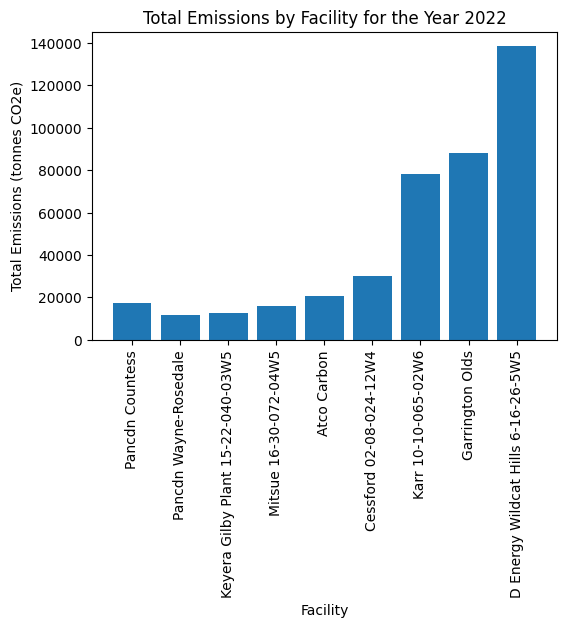

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.bar(
    x='name', height='total_emissions__tonnes_co2e',
    data=ghg_22.head(10).sort_values('total_emissions__tonnes_co2e')
)
plt.xlabel('Facility')
plt.ylabel('Total Emissions (tonnes CO2e)')
plt.title('Total Emissions by Facility for the Year 2022')
plt.xticks(rotation=90)
plt.show()


In [13]:
# Standardize operator names
facilities['current_operator'] = facilities['current_operator'].replace({
    'Altagas Holdings Inc.': 'Altagas Ltd.',
    'Atco Pipelines (North Tn8263923)': 'Atco Energy Solutions Ltd.',
    'Canlin Resources Partnership': 'Canlin Energy Corporation',
    'Conocophillips Canada Resources Corp.': 'Conocophillips Canada',
    'Conocophillips Canada Energy Partnership': 'Conocophillips Canada',
    'Encana Corporation': 'Ovintiv Canada Ulc.',
    'Encana Western Resources Ltd.': 'Ovintiv Canada Ulc.',
    'Exxonmobil Canada Energy': 'Exxonmobil',
    'Inter Pipeline Extraction Ltd.': 'Inter Pipeline',
    'Inter Pipeline Offgas Ltd.': 'Inter Pipeline',
    'Northriver Midstream Energy Holdings Limited': 'Northriver Midstream',
    'Northriver Midstream Energy Limited': 'Northriver Midstream',
    'Northriver Midstream G And P Canada Inc.': 'Northriver Midstream',
    'Northriver Midstream Inc.': 'Northriver Midstream',
    'Northriver Midstream Operations Gp Inc.': 'Northriver Midstream',
    'Pembina Gas Services Ltd.': 'Pembina Pipeline',
    'Pembina Ngl Corporation': 'Pembina Pipeline',
    'Shell Canada Energy': 'Shell Canada Limited',
    'Xto Energy Canada': 'Xto Energy Canada Ulc'
})


In [2]:
import pandas as pd

In [12]:
facilities = pd.read_csv("../data_cleaned/facilities/facilities.csv")

In [9]:
facilities.head()

,id,status,name,type,plant_name,current_operator,co-owner,constructed_date,latitude,longitude,sub_type,location
0,ABGP0001001,Active,Maple Glen 15-36-036-16W4,GP,Maple Glen,Canadian Natural Resources Limited,0.0% - Cansearch Resources Ltd.; 0.0% - Canadi...,NaN,52.14129,-112.15592,Gas Plant Sweet,15-36-036-16W4M
1,ABGP0001002,Suspended,Keyera Nevis Gas Plant 16-33-38-22W4,GP,Nevis,Keyera Energy Ltd.,100.0% - Keyera Energy Ltd.,1956-01-01,52.31647,-113.07704,Gas Plant Sulphur Recovery,16-33-038-22W4M
2,ABGP0001003,Suspended,Gulf Pincher Creek,GP,Pincher Creek,Gulf Canada Limited,100.0% - Palmer Ranch (1984) Ltd.,NaN,49.30742,-113.79413,Gas Plant Sulphur Recovery,01-23-004-29W4M
3,ABGP0001004,Active,Keyera Homeglen-Rimbey 2-05-44-01W5,GP,Rimbey,Keyera Energy Ltd.,0.0% - Centipede Holdings Ltd.; 0.8% - Bellatr...,1961-01-01,52.75748,-114.10701,Gas Plant Sulphur Recovery,02-05-044-01W5M
4,ABGP0001005,Suspended,Gulf Gilby,GP,Gilby,I3 Energy Canada Ltd.,100.0% - I3 Energy Canada Ltd.,NaN,52.44119,-114.30526,Gas Plant Sweet,06-13-040-03W5M


In [16]:
facilities.to_csv("../data_cleaned/facilities/facilities.csv", index=False)

In [17]:
facilities = pd.read_csv("../data_cleaned/facilities/facilities.csv")
facilities.head()

,id,status,name,type,plant_name,current_operator,co-owner,constructed_date,latitude,longitude,sub_type,location
0,ABGP0001001,Active,Maple Glen 15-36-036-16W4,GP,Maple Glen,Canadian Natural Resources Limited,0.0% - Cansearch Resources Ltd.; 0.0% - Canadi...,NaN,52.14129,-112.15592,Gas Plant Sweet,15-36-036-16W4M
1,ABGP0001002,Suspended,Keyera Nevis Gas Plant 16-33-38-22W4,GP,Nevis,Keyera Energy Ltd.,100.0% - Keyera Energy Ltd.,1956-01-01,52.31647,-113.07704,Gas Plant Sulphur Recovery,16-33-038-22W4M
2,ABGP0001003,Suspended,Gulf Pincher Creek,GP,Pincher Creek,Gulf Canada Limited,100.0% - Palmer Ranch (1984) Ltd.,NaN,49.30742,-113.79413,Gas Plant Sulphur Recovery,01-23-004-29W4M
3,ABGP0001004,Active,Keyera Homeglen-Rimbey 2-05-44-01W5,GP,Rimbey,Keyera Energy Ltd.,0.0% - Centipede Holdings Ltd.; 0.8% - Bellatr...,1961-01-01,52.75748,-114.10701,Gas Plant Sulphur Recovery,02-05-044-01W5M
4,ABGP0001005,Suspended,Gulf Gilby,GP,Gilby,I3 Energy Canada Ltd.,100.0% - I3 Energy Canada Ltd.,NaN,52.44119,-114.30526,Gas Plant Sweet,06-13-040-03W5M


In [15]:
sorted(pd.read_csv("../data_cleaned/facilities/facilities.csv")['current_operator'].unique())

['1333002 Alberta Ltd.',
 '177293 Canada Ltd.',
 '2349507 Canada Inc.',
 '2354890 Alberta Ltd.',
 '2363750 Alberta Ltd.',
 '625894 Alberta Inc.',
 '7246366 Canada Ltd.',
 'Acquisition Oil Corp.',
 'Adanac Oil & Gas Limited',
 'Advantage Energy Ltd.',
 'Aitken Creek Gas Storage Ulc',
 'Allied Energy Ii Corp.',
 'Alphabow Energy Ltd.',
 'Altagas Ltd.',
 'Altana Exploration Company',
 'Amber Energy Inc.',
 'Anterra Energy Inc.',
 'Aqt Water Management Inc.',
 'Arc Resources Ltd.',
 'Archer Exploration Corp.',
 'Artis Exploration Ltd.',
 'Aspenleaf Energy Limited',
 'Astara Energy Corp.',
 'Atco Energy Solutions Ltd.',
 'Atco Next Energy Ltd.',
 'Athabasca Oil Corporation',
 'Avila Energy Corporation',
 'Avord Oil & Gas Ltd',
 'Axiom Oil And Gas Inc.',
 'Barnwell Of Canada; Limited',
 'Barrel Oil Corp.',
 'Battle River Energy Ltd.',
 'Baytex Energy Ltd.',
 'Bearspaw Petroleum Ltd.',
 'Bench Creek Resources Ltd.',
 'Birchcliff Energy Ltd.',
 'Blue Range Resource Corporation',
 'Blue Sky Res